In [8]:

library(tidyverse)
library(lubridate)
library(TTR)
library(zoo)
library(xgboost)
library(yardstick)
library(ggplot2)

cat("✓ All packages loaded\n")

✓ All packages loaded


In [10]:
data_path <- "/kaggle/input/datasets/innacampo/s-and-p-500-stocks-daily-historical-data-10-years/SP500_Data_10Y"

files <- list.files(data_path, pattern = "\\.csv$", full.names = TRUE)
cat("Files found:", length(files), "\n")

df_raw <- files %>%
  map_dfr(function(f) {
    ticker <- tools::file_path_sans_ext(basename(f))
    
    df <- read_csv(f, show_col_types = FALSE)
    df <- df[-c(1,2), ]                        # remove first 2 rows (base R, no conflict)
    colnames(df)[1] <- "Date"                  # rename Price → Date
    
    df %>%
      mutate(
        Symbol = ticker,
        Date   = as.Date(Date),
        Close  = as.numeric(Close),
        High   = as.numeric(High),
        Low    = as.numeric(Low),
        Open   = as.numeric(Open),
        Volume = as.numeric(Volume)
      )
  })

cat("✓ Merged\n")
cat("Rows:", nrow(df_raw), "\n")
cat("Cols:", ncol(df_raw), "\n")
print(head(df_raw, 5))

Files found: 501 
✓ Merged
Rows: 1220725 
Cols: 7 
# A tibble: 5 × 7
  Date       Close  High   Low  Open  Volume Symbol
  <date>     <dbl> <dbl> <dbl> <dbl>   <dbl> <chr> 
1 2015-12-21  37.7  37.9  37.3  37.4 1734500 A     
2 2015-12-22  38.0  38.1  37.6  37.8 1643200 A     
3 2015-12-23  38.5  38.6  38.2  38.4 1510700 A     
4 2015-12-24  38.9  39.0  38.4  38.5  874500 A     
5 2015-12-28  38.5  38.8  38.3  38.8 1458200 A     


In [11]:
cat("── Column Names ──\n")
print(names(df_raw))

cat("\n── Types ──\n")
glimpse(df_raw)

cat("\n── Missing Values ──\n")
print(colSums(is.na(df_raw)))

cat("\n── Date Range ──\n")
cat(as.character(min(df_raw$Date, na.rm = TRUE)), "→",
    as.character(max(df_raw$Date, na.rm = TRUE)), "\n")

cat("\n── Unique Tickers ──\n")
cat(n_distinct(df_raw$Symbol), "\n")

print(head(df_raw, 10))

── Column Names ──
[1] "Date"   "Close"  "High"   "Low"    "Open"   "Volume" "Symbol"

── Types ──
Rows: 1,220,725
Columns: 7
$ Date   <date> 2015-12-21, 2015-12-22, 2015-12-23, 2015-12-24, 2015-12-28, 20…
$ Close  <dbl> 37.66288, 38.02261, 38.52996, 38.87126, 38.53918, 39.07420, 38.…
$ High   <dbl> 37.93039, 38.12408, 38.61298, 38.98195, 38.81591, 39.18489, 39.…
$ Low    <dbl> 37.30313, 37.56140, 38.17944, 38.43772, 38.29935, 38.66832, 38.…
$ Open   <dbl> 37.36770, 37.82890, 38.39159, 38.54841, 38.76057, 38.81592, 39.…
$ Volume <dbl> 1734500, 1643200, 1510700, 874500, 1458200, 1757000, 834300, 14…
$ Symbol <chr> "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A"…

── Missing Values ──
  Date  Close   High    Low   Open Volume Symbol 
     0      0      0      0      0      0      0 

── Date Range ──
2015-12-21 → 2025-12-19 

── Unique Tickers ──
501 
# A tibble: 10 × 7
   Date       Close  High   Low  Open  Volume Symbol
   <date>     <dbl> <dbl> <dbl> <dbl>   <dbl> <chr

In [12]:
cat("── Missing Values ──\n")
print(colSums(is.na(df_raw)))

cat("\n── Date Range ──\n")
cat(as.character(min(df_raw$Date, na.rm = TRUE)), "→",
    as.character(max(df_raw$Date, na.rm = TRUE)), "\n")

cat("\n── Unique Tickers ──\n")
cat(n_distinct(df_raw$Symbol), "tickers\n")

print(head(df_raw, 10))

── Missing Values ──
  Date  Close   High    Low   Open Volume Symbol 
     0      0      0      0      0      0      0 

── Date Range ──
2015-12-21 → 2025-12-19 

── Unique Tickers ──
501 tickers
# A tibble: 10 × 7
   Date       Close  High   Low  Open  Volume Symbol
   <date>     <dbl> <dbl> <dbl> <dbl>   <dbl> <chr> 
 1 2015-12-21  37.7  37.9  37.3  37.4 1734500 A     
 2 2015-12-22  38.0  38.1  37.6  37.8 1643200 A     
 3 2015-12-23  38.5  38.6  38.2  38.4 1510700 A     
 4 2015-12-24  38.9  39.0  38.4  38.5  874500 A     
 5 2015-12-28  38.5  38.8  38.3  38.8 1458200 A     
 6 2015-12-29  39.1  39.2  38.7  38.8 1757000 A     
 7 2015-12-30  38.9  39.1  38.8  39.1  834300 A     
 8 2015-12-31  38.7  39.2  38.6  38.8 1451000 A     
 9 2016-01-04  37.6  38.1  37.3  38.0 3287300 A     
10 2016-01-05  37.5  37.9  37.3  37.7 2587200 A     


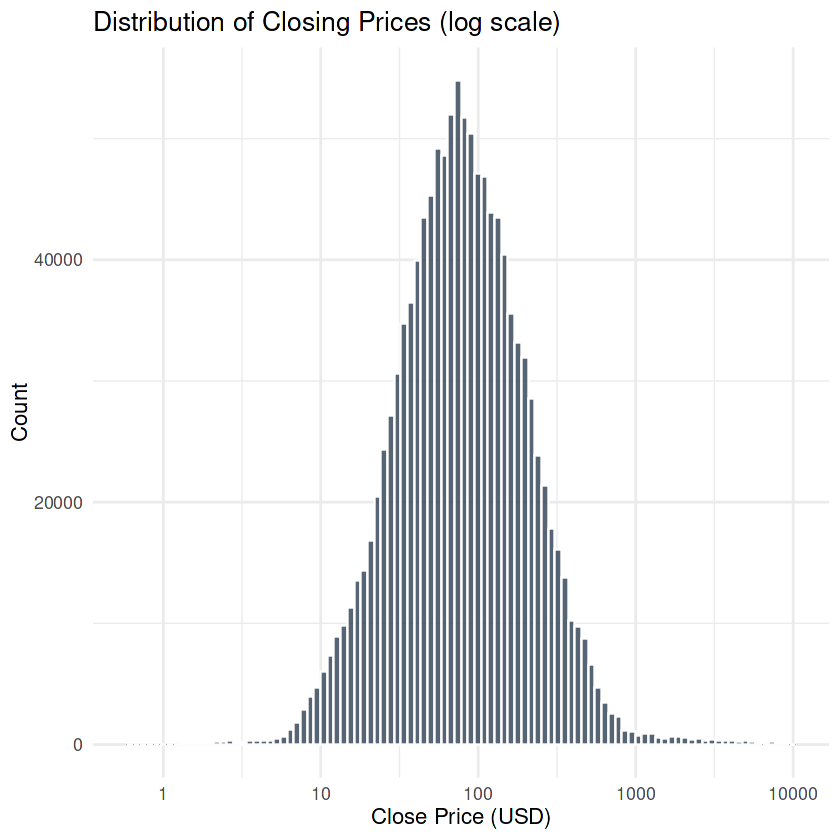

In [13]:
ggplot(df_raw, aes(x = Close)) +
  geom_histogram(bins = 100, fill = "#2C3E50", color = "white", alpha = 0.8) +
  scale_x_log10() +
  labs(title = "Distribution of Closing Prices (log scale)",
       x = "Close Price (USD)", y = "Count") +
  theme_minimal(base_size = 13)

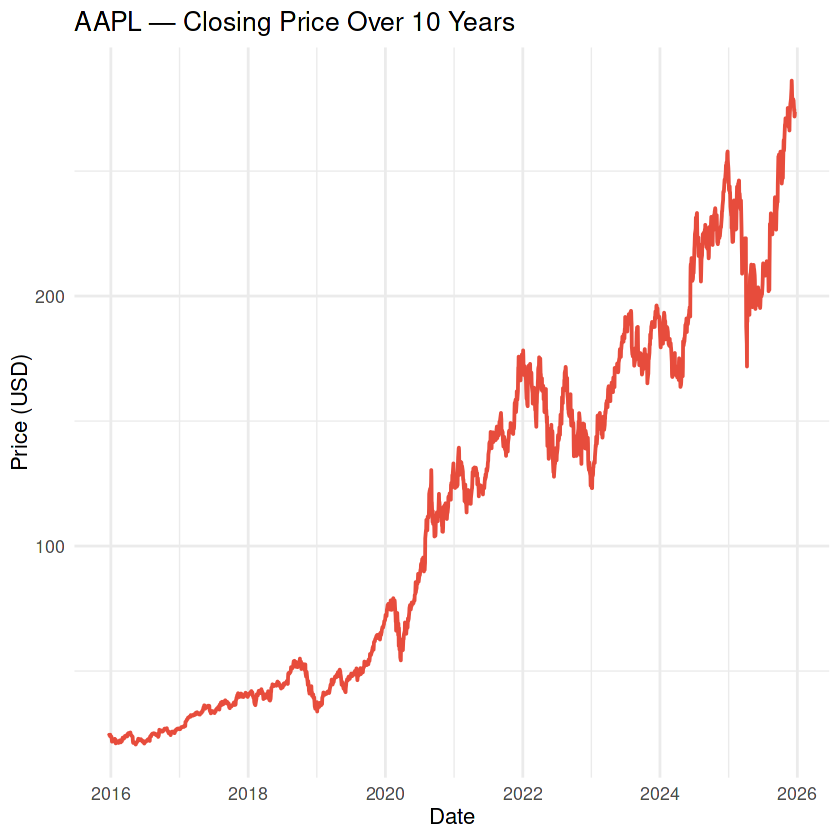

In [14]:
df_raw %>%
  filter(Symbol == "AAPL") %>%
  ggplot(aes(x = Date, y = Close)) +
  geom_line(color = "#E74C3C", linewidth = 0.8) +
  labs(title = "AAPL — Closing Price Over 10 Years",
       x = "Date", y = "Price (USD)") +
  theme_minimal(base_size = 13)

In [15]:
df <- df_raw %>%
  arrange(Symbol, Date) %>%
  group_by(Symbol) %>%
  mutate(
    return_1d      = (Close - lag(Close))     / lag(Close),
    return_5d      = (Close - lag(Close, 5))  / lag(Close, 5),
    return_20d     = (Close - lag(Close, 20)) / lag(Close, 20),
    lag1_return    = lag(return_1d, 1),
    lag2_return    = lag(return_1d, 2),
    lag5_return    = lag(return_1d, 5),

    ma_5           = rollmean(Close, 5,  fill = NA, align = "right"),
    ma_20          = rollmean(Close, 20, fill = NA, align = "right"),
    ma_50          = rollmean(Close, 50, fill = NA, align = "right"),

    price_vs_ma5   = Close / ma_5  - 1,
    price_vs_ma20  = Close / ma_20 - 1,
    price_vs_ma50  = Close / ma_50 - 1,
    ma_5_20_cross  = ma_5  / ma_20 - 1,
    ma_20_50_cross = ma_20 / ma_50 - 1,

    volatility_5d  = rollapply(return_1d, 5,  sd, fill = NA, align = "right"),
    volatility_20d = rollapply(return_1d, 20, sd, fill = NA, align = "right"),
    vol_ratio_5_20 = volatility_5d / volatility_20d,

    vol_change     = (Volume - lag(Volume)) / lag(Volume),
    vol_ma5        = rollmean(Volume, 5, fill = NA, align = "right"),
    vol_vs_ma5     = Volume / vol_ma5,

    high_low_range = (High - Low) / Close,
    close_position = (Close - Low) / (High - Low),
    overnight_gap  = (Open - lag(Close)) / lag(Close),

    rsi_14         = RSI(Close, n = 14),

    ema_12         = EMA(Close, n = 12),
    ema_26         = EMA(Close, n = 26),
    macd           = ema_12 - ema_26,
    macd_signal    = EMA(macd, n = 9),
    macd_hist      = macd - macd_signal,

    bb_sd          = rollapply(Close, 20, sd, fill = NA, align = "right"),
    bb_upper       = ma_20 + 2 * bb_sd,
    bb_lower       = ma_20 - 2 * bb_sd,
    bb_position    = (Close - bb_lower) / (bb_upper - bb_lower),

    day_of_week    = wday(Date, label = FALSE),
    month          = month(Date),
    quarter        = quarter(Date),

    target_price     = lead(Close, 1),
    target_direction = as.factor(ifelse(lead(Close,1) > Close, 1, 0)),
    target_return_5d = (lead(Close, 5) - Close) / Close * 100
  ) %>%
  select(-ema_12, -ema_26, -bb_sd, -bb_upper, -bb_lower) %>%
  ungroup() %>%
  drop_na()

cat("✓ Done | Rows:", nrow(df), "| Cols:", ncol(df), "\n")

✓ Done | Rows: 1191153 | Cols: 41 


In [16]:
df %>%
  select(Symbol, Date, return_1d, rsi_14, macd, bb_position,
         target_price, target_direction, target_return_5d) %>%
  head(10) %>% print()

cat("\n── Case 2 Class Balance ──\n")
print(prop.table(table(df$target_direction)))

# A tibble: 10 × 9
   Symbol Date       return_1d rsi_14  macd bb_position target_price
   <chr>  <date>         <dbl>  <dbl> <dbl>       <dbl>        <dbl>
 1 A      2016-03-03   0.00410   60.8 0.136       0.928         36.4
 2 A      2016-03-04   0.00357   61.6 0.229       0.905         36.5
 3 A      2016-03-07   0.00229   62.1 0.306       0.873         35.2
 4 A      2016-03-08  -0.0340    50.9 0.264       0.608         35.3
 5 A      2016-03-09   0.00105   51.2 0.231       0.596         35.1
 6 A      2016-03-10  -0.00393   50.1 0.191       0.542         36.3
 7 A      2016-03-11   0.0329    58.5 0.250       0.846         36.1
 8 A      2016-03-14  -0.00535   56.8 0.278       0.771         35.4
 9 A      2016-03-15  -0.0187    51.1 0.243       0.528         36.1
10 A      2016-03-16   0.0180    55.6 0.263       0.730         36.3
# ℹ 2 more variables: target_direction <fct>, target_return_5d <dbl>

── Case 2 Class Balance ──

        0         1 
0.4745243 0.5254757 


In [18]:
sorted_dates <- sort(unique(df$Date))
split_date   <- sorted_dates[floor(length(sorted_dates) * 0.80)]

train <- df %>% filter(Date <= split_date)
test  <- df %>% filter(Date >  split_date)

cat("Split date :", as.character(split_date), "\n")
cat("Train rows :", nrow(train), "\n")
cat("Test rows  :", nrow(test),  "\n")

feature_cols <- df %>%
  select(-Symbol, -Date, -Open, -High, -Low, -Close, -Volume,
         -target_price, -target_direction, -target_return_5d) %>%
  names()

cat("Features   :", length(feature_cols), "\n")

Split date : 2023-12-26 
Train rows : 945820 
Test rows  : 245333 
Features   : 31 


In [21]:
build_dmatrix <- function(data, target_col) {
  X <- data %>% select(all_of(feature_cols)) %>% as.matrix()
  
  # Replace inf/-inf with NA then fill with 0
  X[is.infinite(X)] <- NA
  X[is.nan(X)]      <- NA
  X[is.na(X)]       <- 0
  
  y <- as.numeric(as.character(data[[target_col]]))
  
  xgb.DMatrix(X, label = y)
}

cat("✓ Helper ready\n")

✓ Helper ready


In [22]:
dtrain1 <- build_dmatrix(train, "target_price")
dtest1  <- build_dmatrix(test,  "target_price")

set.seed(42)
model1 <- xgb.train(
  params = list(objective = "reg:squarederror", eval_metric = "rmse",
                eta = 0.05, max_depth = 6, subsample = 0.8,
                colsample_bytree = 0.8, min_child_weight = 10),
  data                  = dtrain1,
  nrounds               = 500,
  watchlist             = list(train = dtrain1, test = dtest1),
  early_stopping_rounds = 30,
  verbose               = 1,
  print_every_n         = 50
)

[1]	train-rmse:245.289846	test-rmse:486.037379 
Multiple eval metrics are present. Will use test_rmse for early stopping.
Will train until test_rmse hasn't improved in 30 rounds.

[51]	train-rmse:20.030078	test-rmse:97.184876 
[101]	train-rmse:4.684441	test-rmse:68.744922 
[151]	train-rmse:4.147046	test-rmse:66.938075 
[201]	train-rmse:4.017000	test-rmse:66.780630 
Stopping. Best iteration:
[184]	train-rmse:4.056164	test-rmse:66.717868



In [23]:
pred1   <- predict(model1, dtest1)
actual1 <- test$target_price

rmse1 <- sqrt(mean((pred1 - actual1)^2))
mae1  <- mean(abs(pred1 - actual1))
r2_1  <- 1 - sum((actual1 - pred1)^2) / sum((actual1 - mean(actual1))^2)

cat("RMSE :", round(rmse1, 4), "\n")
cat("MAE  :", round(mae1,  4), "\n")
cat("R²   :", round(r2_1,  4), "\n")

RMSE : 66.7179 
MAE  : 5.2741 
R²   : 0.9793 


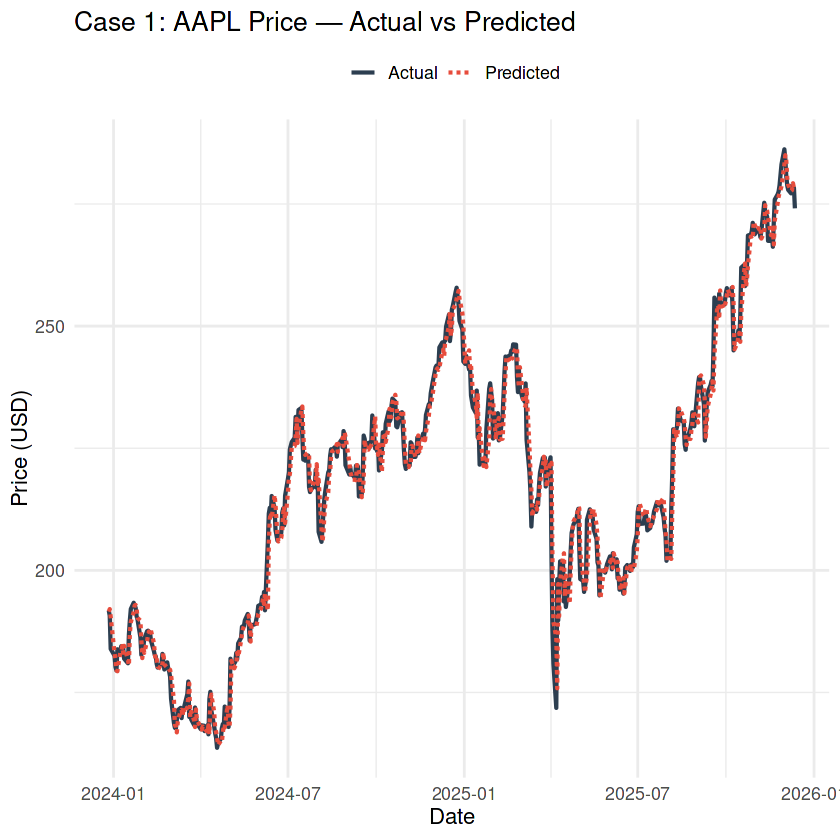

In [24]:
test %>%
  filter(Symbol == "AAPL") %>%
  mutate(predicted = predict(
    model1,
    xgb.DMatrix(select(., all_of(feature_cols)) %>% as.matrix())
  )) %>%
  select(Date, actual = target_price, predicted) %>%
  ggplot(aes(x = Date)) +
  geom_line(aes(y = actual,    color = "Actual"),    linewidth = 0.9) +
  geom_line(aes(y = predicted, color = "Predicted"), linewidth = 0.9, linetype = "dashed") +
  scale_color_manual(values = c("Actual" = "#2C3E50", "Predicted" = "#E74C3C")) +
  labs(title = "Case 1: AAPL Price — Actual vs Predicted",
       x = "Date", y = "Price (USD)", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "top")

In [25]:
dtrain2 <- build_dmatrix(train, "target_direction")
dtest2  <- build_dmatrix(test,  "target_direction")

set.seed(42)
model2 <- xgb.train(
  params = list(objective = "binary:logistic", eval_metric = "auc",
                eta = 0.05, max_depth = 5, subsample = 0.8,
                colsample_bytree = 0.8, min_child_weight = 10,
                scale_pos_weight = sum(train$target_direction == 0) /
                                   sum(train$target_direction == 1)),
  data                  = dtrain2,
  nrounds               = 500,
  watchlist             = list(train = dtrain2, test = dtest2),
  early_stopping_rounds = 30,
  verbose               = 1,
  print_every_n         = 50
)

[1]	train-auc:0.517204	test-auc:0.507786 
Multiple eval metrics are present. Will use test_auc for early stopping.
Will train until test_auc hasn't improved in 30 rounds.

Stopping. Best iteration:
[1]	train-auc:0.517204	test-auc:0.507786



In [26]:
prob2   <- predict(model2, dtest2)
pred2   <- ifelse(prob2 > 0.5, 1, 0)
actual2 <- as.numeric(as.character(test$target_direction))

acc2 <- mean(pred2 == actual2)
auc2 <- roc_auc_vec(
  truth       = factor(actual2, levels = c(0,1)),
  estimate    = prob2,
  event_level = "second"
)

cat("Accuracy :", round(acc2, 4), "\n")
cat("AUC      :", round(auc2, 4), "\n\n")
print(table(Actual = actual2, Predicted = pred2))

Accuracy : 0.5075 
AUC      : 0.5078 

      Predicted
Actual     0     1
     0 58002 59144
     1 61685 66502


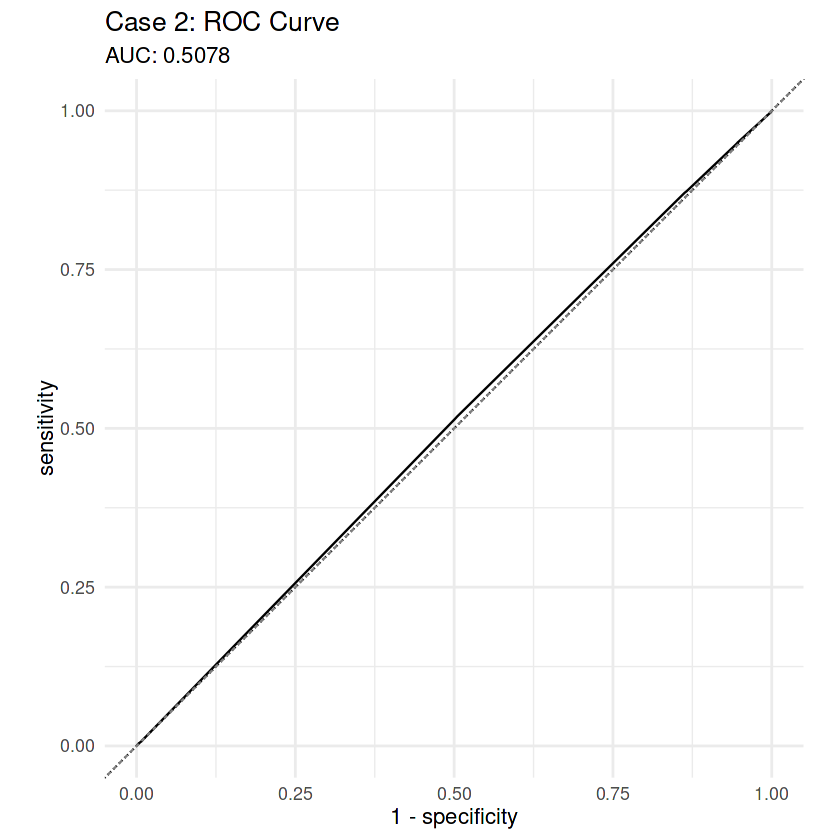

In [27]:
roc_curve(
  data        = tibble(truth = factor(actual2, levels = c(0,1)), prob = prob2),
  truth       = truth,
  prob,
  event_level = "second"
) %>%
  autoplot() +
  geom_abline(linetype = "dashed", color = "gray50") +
  labs(title    = "Case 2: ROC Curve",
       subtitle = paste("AUC:", round(auc2, 4))) +
  theme_minimal(base_size = 13)

In [28]:
dtrain3 <- build_dmatrix(train, "target_return_5d")
dtest3  <- build_dmatrix(test,  "target_return_5d")

set.seed(42)
model3 <- xgb.train(
  params = list(objective = "reg:squarederror", eval_metric = "mae",
                eta = 0.05, max_depth = 6, subsample = 0.8,
                colsample_bytree = 0.8, min_child_weight = 10),
  data                  = dtrain3,
  nrounds               = 500,
  watchlist             = list(train = dtrain3, test = dtest3),
  early_stopping_rounds = 30,
  verbose               = 1,
  print_every_n         = 50
)

[1]	train-mae:3.086169	test-mae:3.096730 
Multiple eval metrics are present. Will use test_mae for early stopping.
Will train until test_mae hasn't improved in 30 rounds.

[51]	train-mae:3.011361	test-mae:3.095592 
Stopping. Best iteration:
[24]	train-mae:3.037239	test-mae:3.093411



In [29]:
pred3   <- predict(model3, dtest3)
actual3 <- test$target_return_5d

rmse3 <- sqrt(mean((pred3 - actual3)^2))
mae3  <- mean(abs(pred3 - actual3))
r2_3  <- 1 - sum((actual3 - pred3)^2) / sum((actual3 - mean(actual3))^2)

cat("RMSE :", round(rmse3, 4), "\n")
cat("MAE  :", round(mae3,  4), "\n")
cat("R²   :", round(r2_3,  4), "\n")

RMSE : 4.4697 
MAE  : 3.0934 
R²   : 0.0019 


`geom_smooth()` using formula = 'y ~ x'


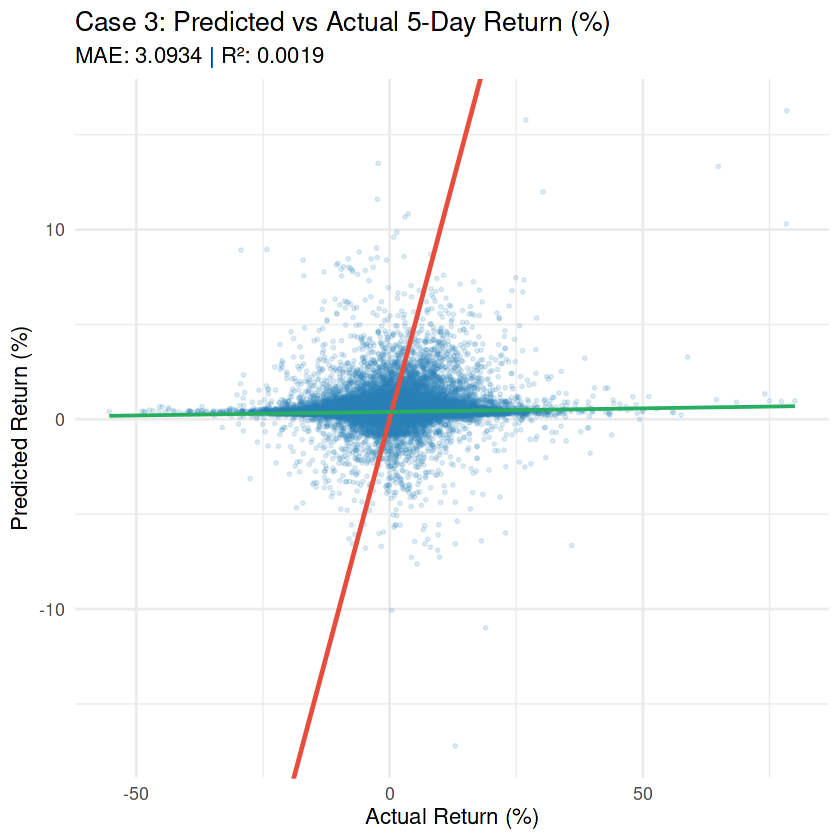

In [30]:
ggplot(data.frame(actual = actual3, predicted = pred3),
       aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.15, size = 0.6, color = "#2980B9") +
  geom_abline(slope = 1, intercept = 0, color = "#E74C3C", linewidth = 1) +
  geom_smooth(method = "lm", se = FALSE, color = "#27AE60", linewidth = 0.8) +
  labs(title    = "Case 3: Predicted vs Actual 5-Day Return (%)",
       subtitle = paste("MAE:", round(mae3, 4), "| R²:", round(r2_3, 4)),
       x = "Actual Return (%)", y = "Predicted Return (%)") +
  theme_minimal(base_size = 13)

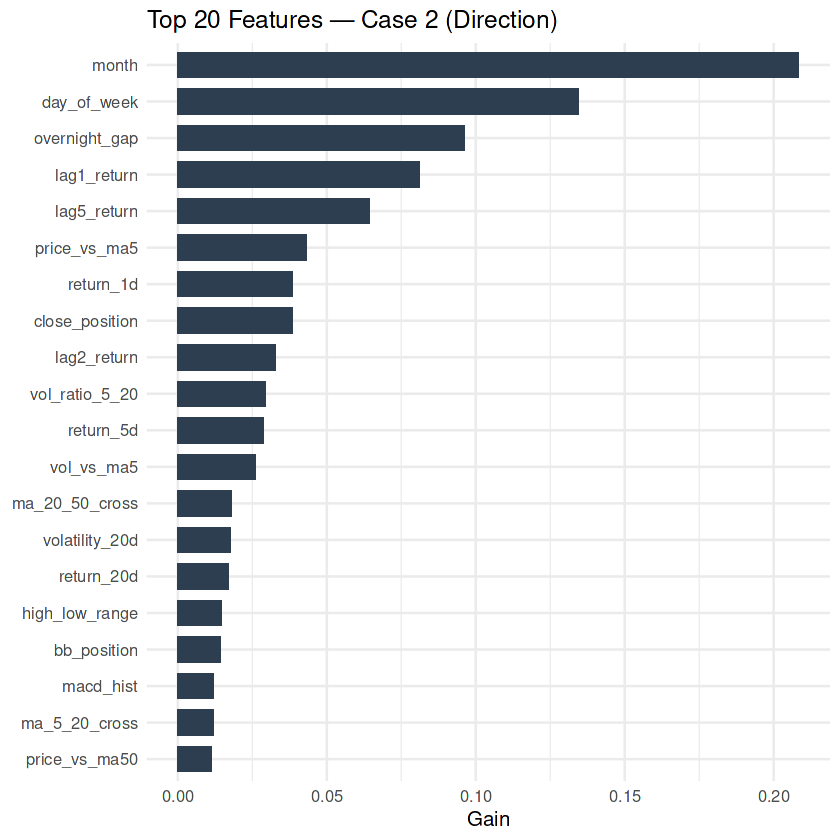

In [31]:
xgb.importance(feature_names = feature_cols, model = model2) %>%
  head(20) %>%
  ggplot(aes(x = reorder(Feature, Gain), y = Gain)) +
  geom_col(fill = "#2C3E50", width = 0.7) +
  coord_flip() +
  labs(title = "Top 20 Features — Case 2 (Direction)", x = NULL, y = "Gain") +
  theme_minimal(base_size = 12)

In [32]:
tibble(
  Case     = c("Case 1 — Price", "Case 2 — Direction", "Case 3 — 5d Return"),
  Metric1  = c(paste("RMSE:", round(rmse1,4)), paste("Acc:", round(acc2,4)), paste("RMSE:", round(rmse3,4))),
  Metric2  = c(paste("MAE:",  round(mae1,4)),  paste("AUC:", round(auc2,4)), paste("MAE:",  round(mae3,4))),
  R2       = c(round(r2_1,4), NA, round(r2_3,4))
) %>% print()

# A tibble: 3 × 4
  Case               Metric1       Metric2          R2
  <chr>              <chr>         <chr>         <dbl>
1 Case 1 — Price     RMSE: 66.7179 MAE: 5.2741  0.979 
2 Case 2 — Direction Acc: 0.5075   AUC: 0.5078 NA     
3 Case 3 — 5d Return RMSE: 4.4697  MAE: 3.0934  0.0019


In [33]:
export_df <- test %>%
  select(Symbol, Date, Open, High, Low, Close, Volume,
         target_price, target_direction, target_return_5d) %>%
  mutate(
    # Case 1 predictions
    pred_price      = predict(model1, dtest1),
    
    # Case 2 predictions
    pred_prob_up    = predict(model2, dtest2),
    pred_direction  = ifelse(pred_prob_up > 0.5, "Up", "Down"),
    actual_direction = ifelse(target_direction == 1, "Up", "Down"),
    direction_correct = pred_direction == actual_direction,
    
    # Case 3 predictions
    pred_return_5d  = predict(model3, dtest3),
    
    # Errors
    price_error     = pred_price - target_price,
    return_error    = pred_return_5d - target_return_5d
  )

cat("✓ Export dataset ready\n")
cat("Rows:", nrow(export_df), "\n")
print(head(export_df, 5))

✓ Export dataset ready
Rows: 245333 
# A tibble: 5 × 18
  Symbol Date        Open  High   Low Close Volume target_price target_direction
  <chr>  <date>     <dbl> <dbl> <dbl> <dbl>  <dbl>        <dbl> <fct>           
1 A      2023-12-27  138.  138.  137.  138. 1.18e6         138. 0               
2 A      2023-12-28  138.  139.  138.  138. 8.93e5         137. 0               
3 A      2023-12-29  137.  138.  137.  137. 1.01e6         137. 0               
4 A      2024-01-02  136.  139.  136.  137. 1.44e6         129. 0               
5 A      2024-01-03  136.  136.  129.  129. 2.07e6         129. 0               
# ℹ 9 more variables: target_return_5d <dbl>, pred_price <dbl>,
#   pred_prob_up <dbl>, pred_direction <chr>, actual_direction <chr>,
#   direction_correct <lgl>, pred_return_5d <dbl>, price_error <dbl>,
#   return_error <dbl>


In [34]:
write_csv(export_df, "/kaggle/working/sp500_predictions.csv")

# Feature importance for Power BI
xgb.importance(feature_names = feature_cols, model = model2) %>%
  write_csv("/kaggle/working/feature_importance.csv")

# Summary metrics
tibble(
  Case     = c("Price Regression", "Direction Classification", "5D Return Regression"),
  RMSE     = c(round(rmse1,4), NA, round(rmse3,4)),
  MAE      = c(round(mae1,4),  NA, round(mae3,4)),
  R2       = c(round(r2_1,4),  NA, round(r2_3,4)),
  Accuracy = c(NA, round(acc2,4), NA),
  AUC      = c(NA, round(auc2,4), NA)
) %>%
  write_csv("/kaggle/working/model_metrics.csv")

cat("✓ Files saved to /kaggle/working/\n")
cat("Files:\n")
print(list.files("/kaggle/working/"))

✓ Files saved to /kaggle/working/
Files:
[1] "feature_importance.csv" "model_metrics.csv"      "sp500_predictions.csv" 
